# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
display(df_reviews.head())

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


Initial look to ensure data was imported properly.

In [6]:
print(df_reviews.info())
print('total missing data', df_reviews.isna().sum())
print('total number of duplicates', df_reviews.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [7]:
df_reviews = df_reviews.dropna()
print(df_reviews.isna().sum())

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     0
votes              0
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64


After seeing that there was missing data in 2 columns it is easiest to drop them. all data types are normal and we have a clean data set.

In [8]:
print(df_reviews.describe())

         start_year      is_adult  average_rating         votes        rating  \
count  47329.000000  47329.000000    47329.000000  4.732900e+04  47329.000000   
mean    1989.630882      0.001733        5.998278  2.556292e+04      5.484439   
std       19.600702      0.041588        1.494289  8.367004e+04      3.473083   
min     1894.000000      0.000000        1.400000  9.000000e+00      1.000000   
25%     1982.000000      0.000000        5.100000  8.270000e+02      2.000000   
50%     1998.000000      0.000000        6.300000  3.197000e+03      4.000000   
75%     2004.000000      0.000000        7.100000  1.397400e+04      9.000000   
max     2010.000000      1.000000        9.700000  1.739448e+06     10.000000   

                pos           idx  
count  47329.000000  47329.000000  
mean       0.498933   6279.826808  
std        0.500004   3605.724280  
min        0.000000      0.000000  
25%        0.000000   3162.000000  
50%        0.000000   6300.000000  
75%        1.00000

Looking at the data, it seems to be fairly balanced already, no major outliers or deviations.

## EDA

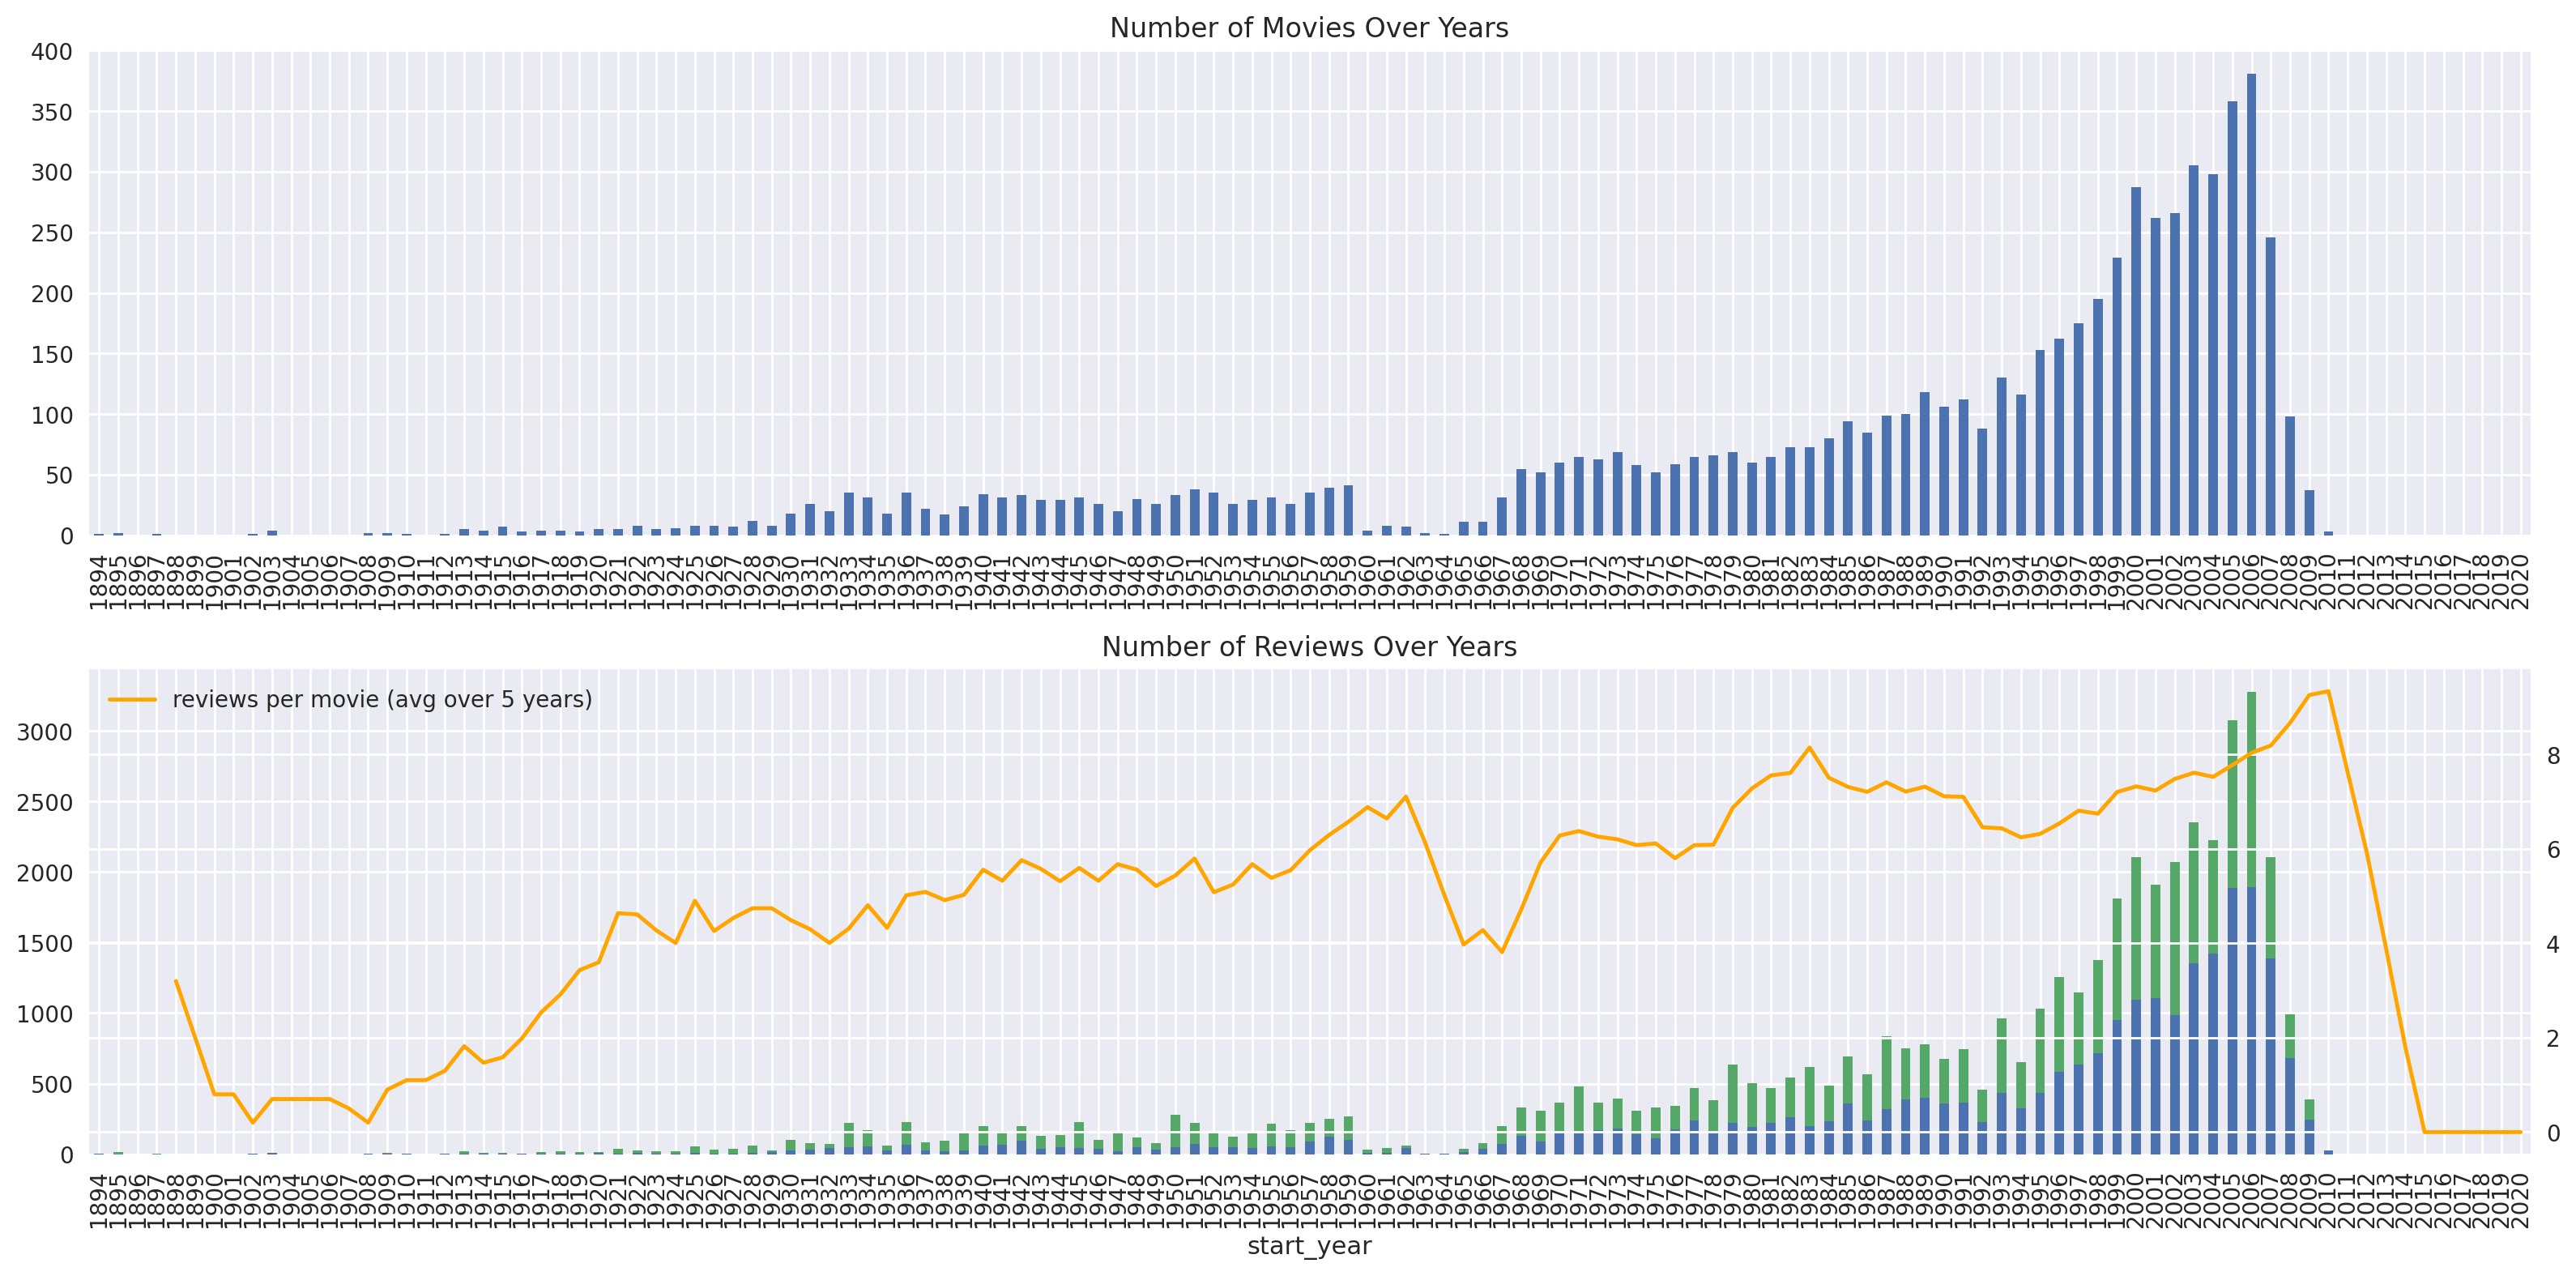

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

The dataset shows movie production and review activity spanning from the late 1800s to around 2010, with a clear increase in both films produced and reviews written starting in the 1980s. Movie production peaks in the 1990s–2000s, and review counts closely follow this trend over time. Across all years, positive and negative reviews remain relatively balanced, suggesting no major class imbalance in sentiment distribution over time.

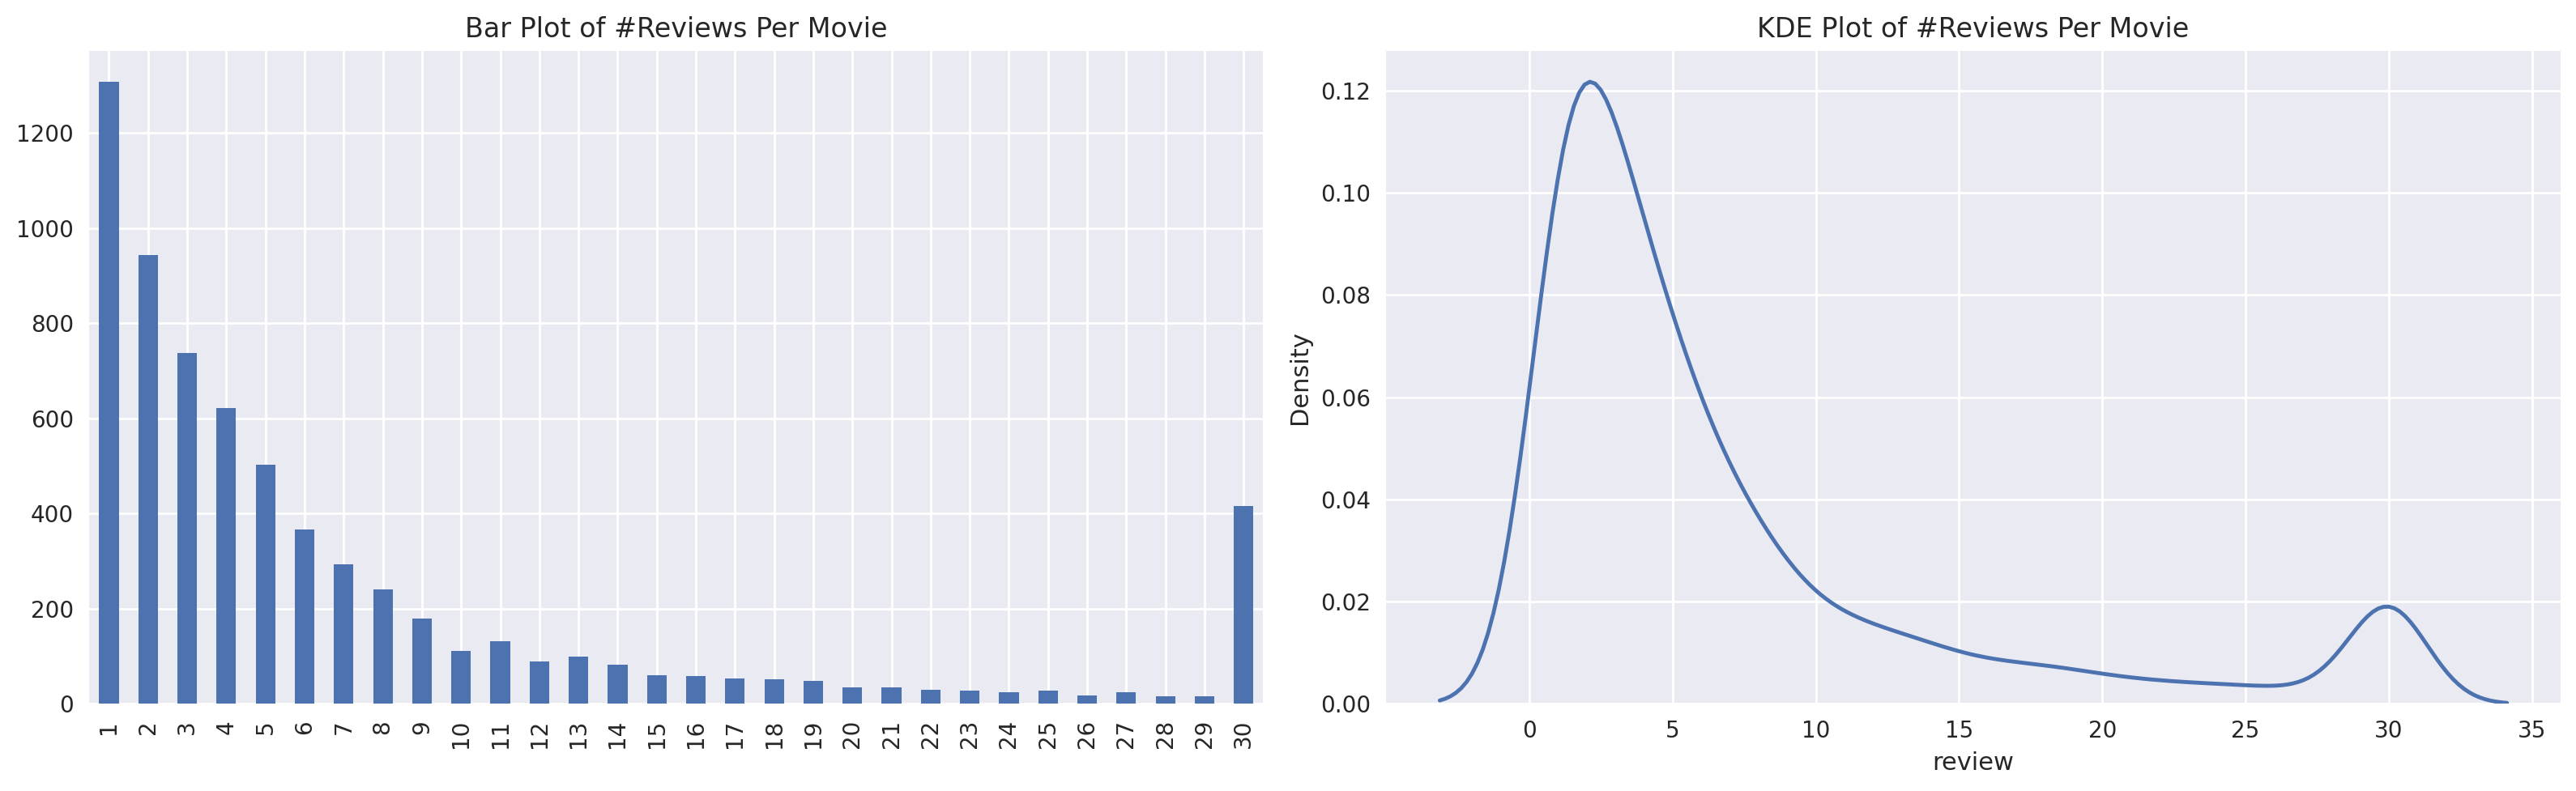

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

The distribution of reviews per movie is highly skewed, with most films receiving only a single review and very few receiving large numbers of reviews. This long-tail pattern is confirmed by both the bar plot and the KDE curve, which show that the majority of movies cluster at the low end of review counts. Overall, the data indicates broad historical coverage of cinema but uneven review attention, where a small number of films receive significantly more engagement than the majority.

In [11]:
df_reviews['pos'].value_counts()

0    23715
1    23614
Name: pos, dtype: int64

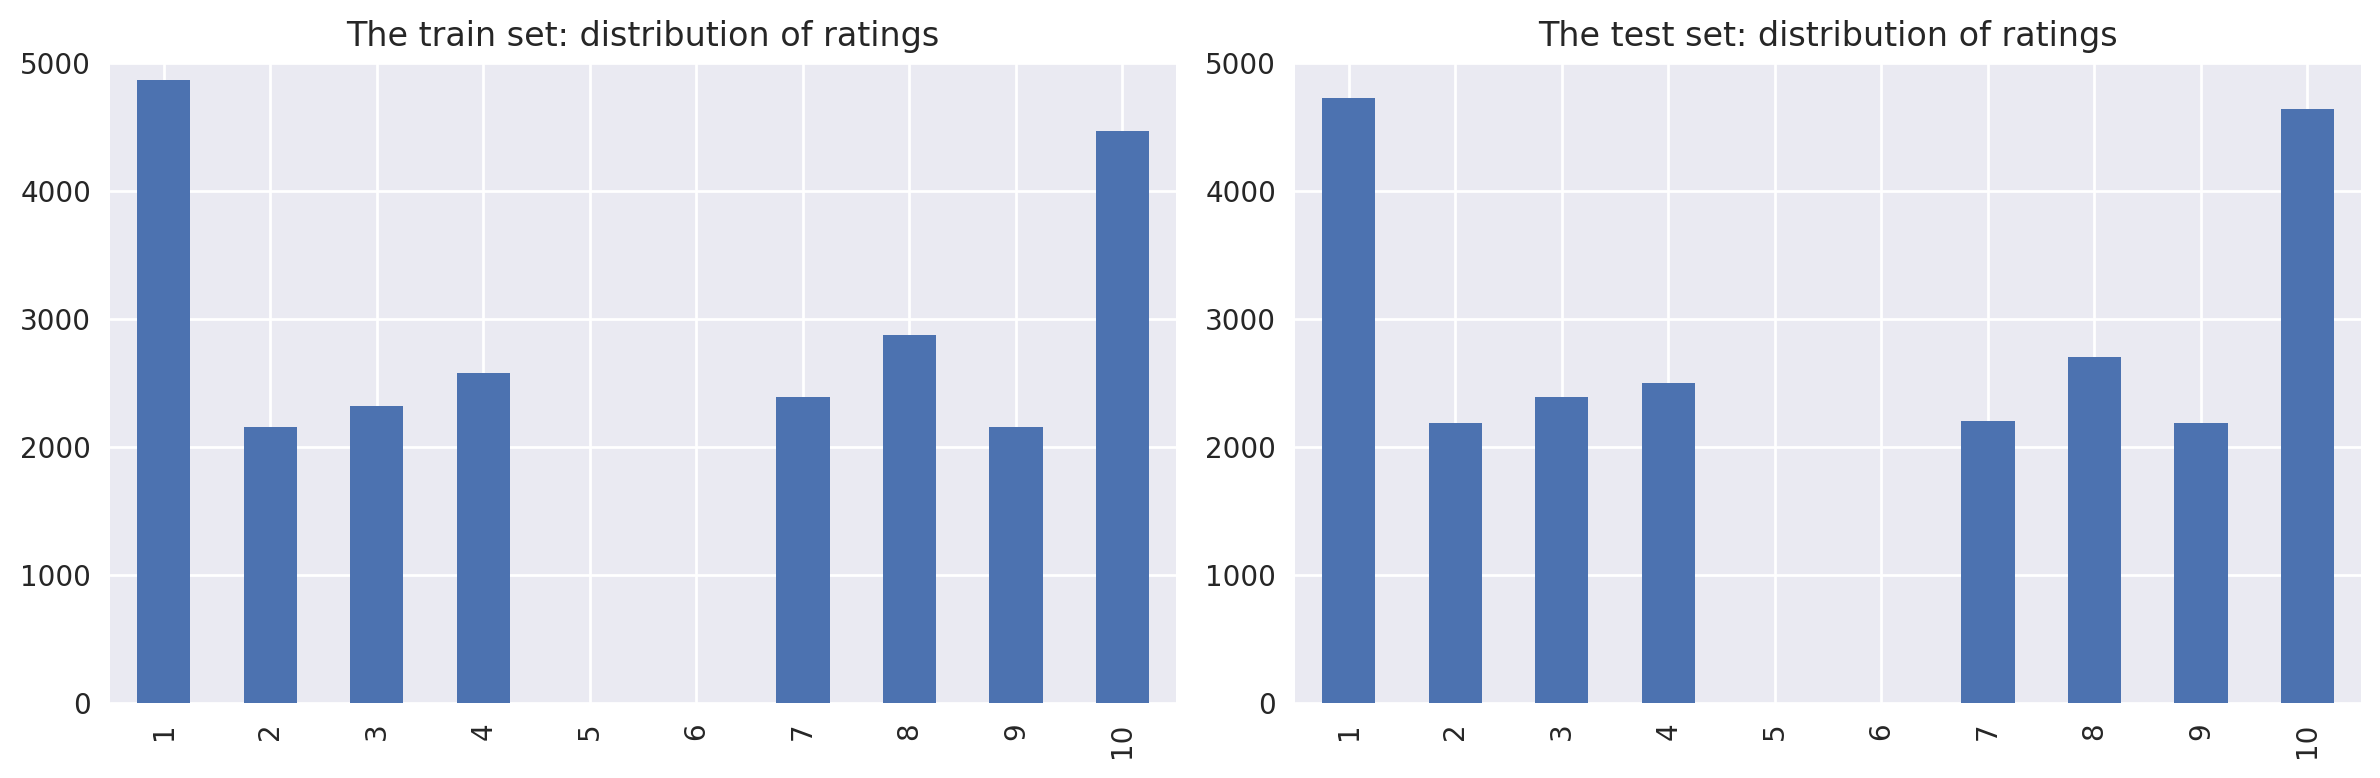

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

The rating distributions in both the training and test sets show a similar U-shaped pattern, with most reviews concentrated at the extremes (ratings 1–2 and 8–10) and relatively few moderate ratings in the middle range. This indicates that user opinions are highly polarized, tending toward very negative or very positive sentiments rather than neutral feedback. The consistency between the train and test sets also confirms that the data split preserved the original distribution, ensuring that model evaluation is reliable and not affected by distribution mismatch.

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


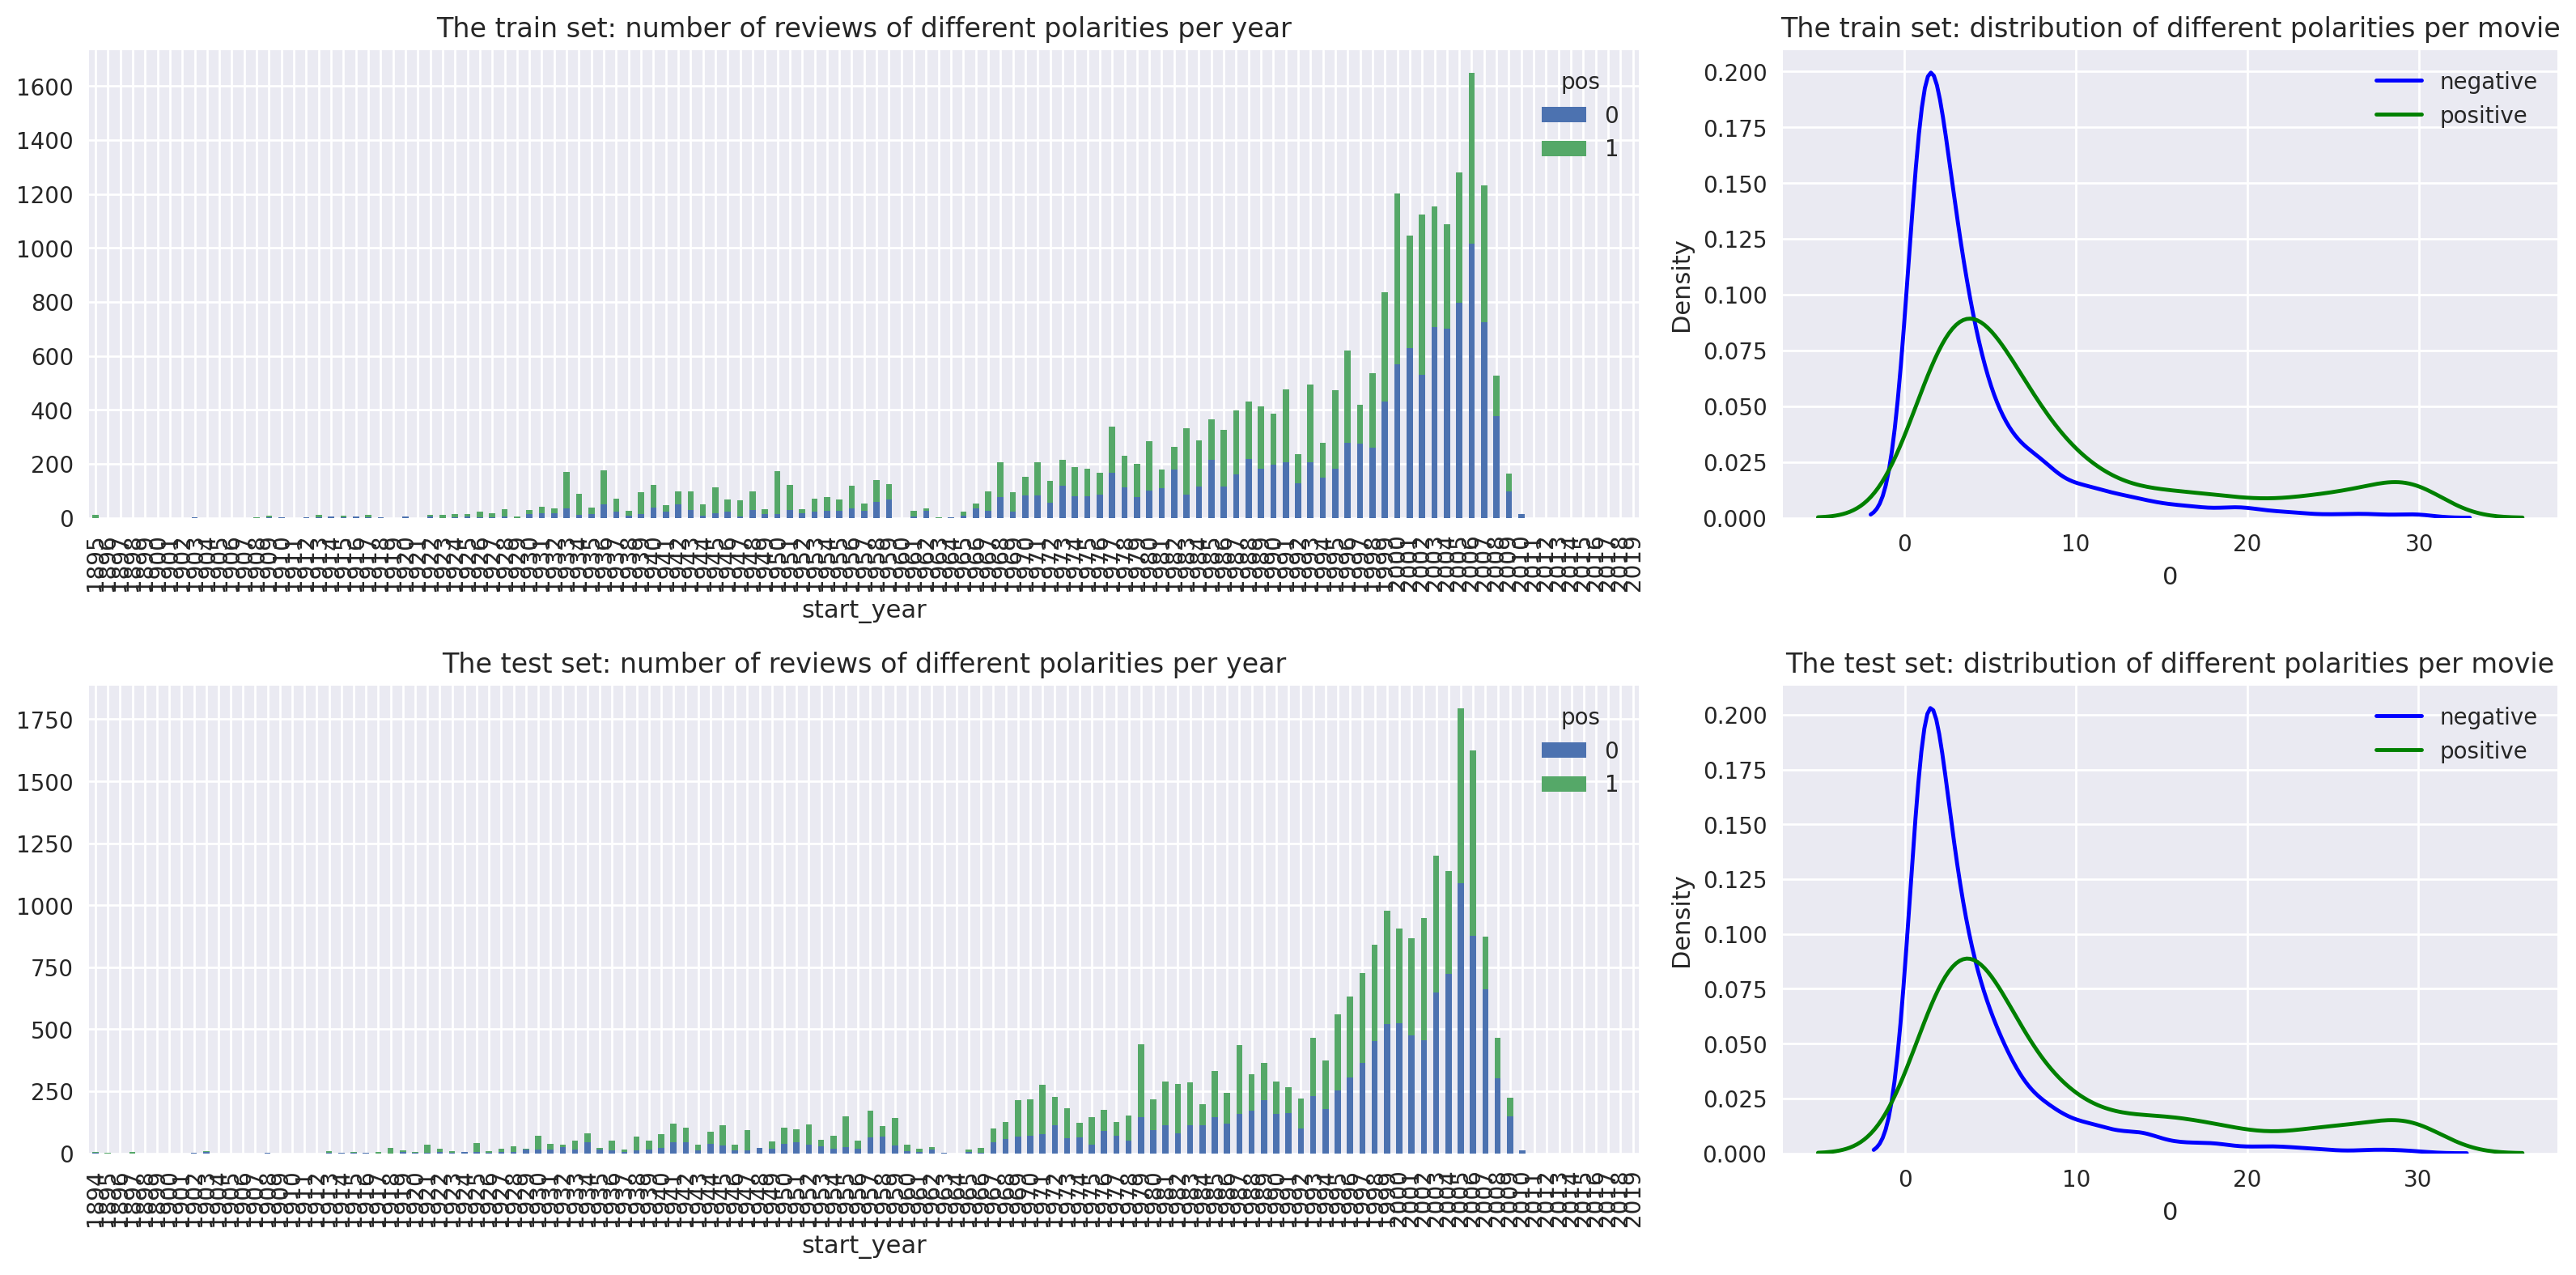

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

The sentiment distribution analysis shows that both the training and test sets are well-balanced across time, with negative and positive reviews appearing in roughly equal proportions each year. Review volume increases notably from the 1980s onward, but there is no evidence of temporal bias toward either sentiment class. This consistency across both datasets indicates that the data is representative and suitable for training a robust sentiment classification model.

Additionally, the distribution of reviews per movie shows nearly identical patterns for positive and negative sentiments in both the training and test sets. The overlapping KDE curves confirm that there is no systematic bias toward either sentiment type at the movie level, meaning films are not disproportionately receiving positive or negative feedback. Overall, the charts demonstrate strong consistency between train and test data, supporting reliable model evaluation.

In [14]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

Composing an evaluation routine which can be used for all models in this project

In [15]:
import re

df_reviews['review_norm'] = df_reviews['review'].apply(lambda x: re.sub(r'[^a-z\s]', '', x.lower()))

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

## Train / Test Split

In [16]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23533, 18)


Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

### Model 1 - Constant

In [17]:
from sklearn.dummy import DummyClassifier

In [18]:
train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

model_1 = DummyClassifier(strategy='constant', constant=1)
model_1.fit(train_features, train_target)

DummyClassifier(constant=1, strategy='constant')

          train  test
Accuracy   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50
None


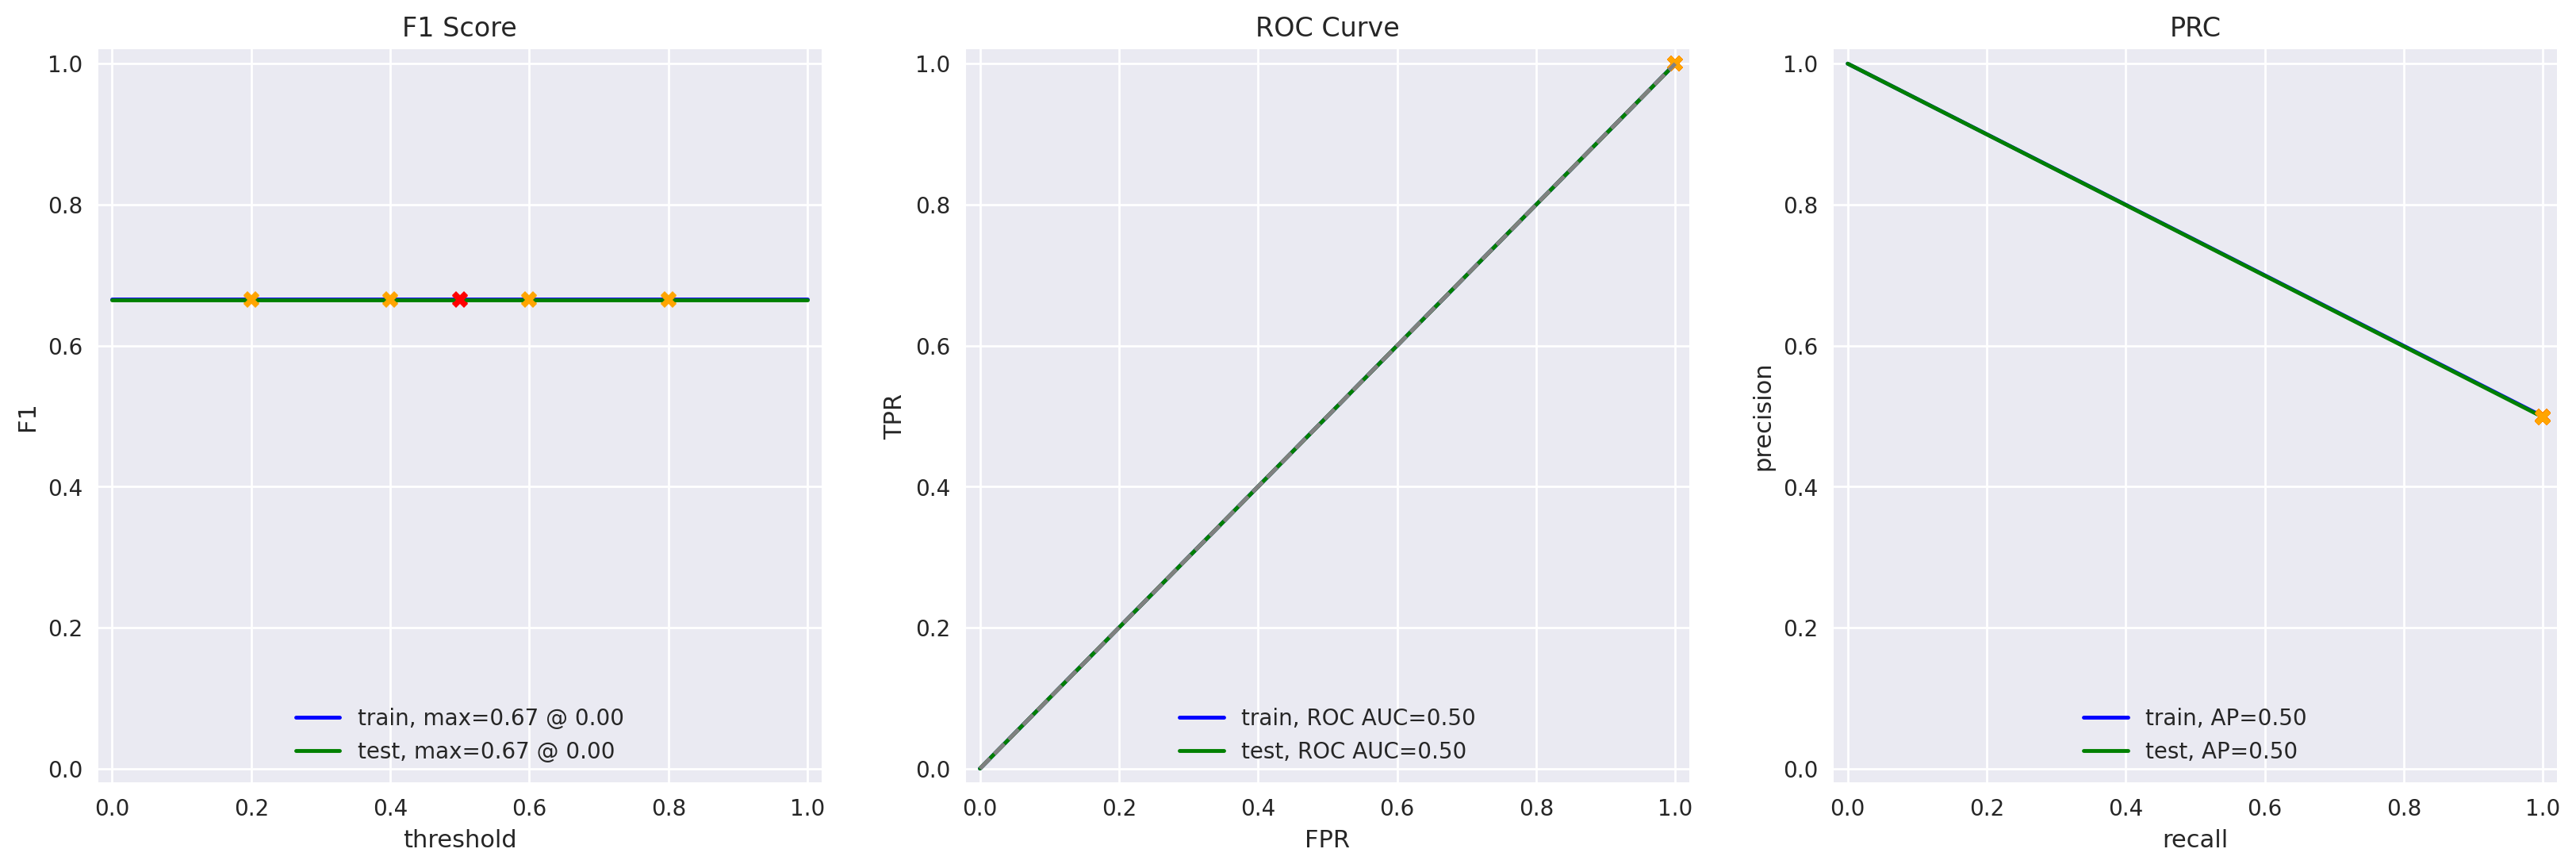

In [19]:
model_1_eval = evaluate_model(model_1, train_features, train_target, test_features, test_target)
print(model_1_eval)

Since the dataset is balanced (about 50% positive, 50% negative reviews), a model that always predicts "positive" will be right about half the time (Accuracy = 0.50).
Have perfect recall for positive class but zero precision for negative class and show no discriminative ability (ROC AUC = 0.50)

In [20]:
import nltk
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [21]:
corpus = df_reviews['review_norm']

review_norm_idx = random.randint(0, len(corpus) - 1)
review_norm = corpus[review_norm_idx]

stop_words = set(stopwords.words('english'))
tfidf_vectorizer_2 = TfidfVectorizer(stop_words=stop_words)
tf_idf = tfidf_vectorizer_2.fit_transform(corpus)

In [22]:
train_features_2 = tfidf_vectorizer_2.transform(df_reviews_train['review_norm'])
test_features_2 = tfidf_vectorizer_2.transform(df_reviews_test['review_norm'])

model_2 = LogisticRegression()
model_2.fit(train_features_2, train_target)

LogisticRegression()

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95
None


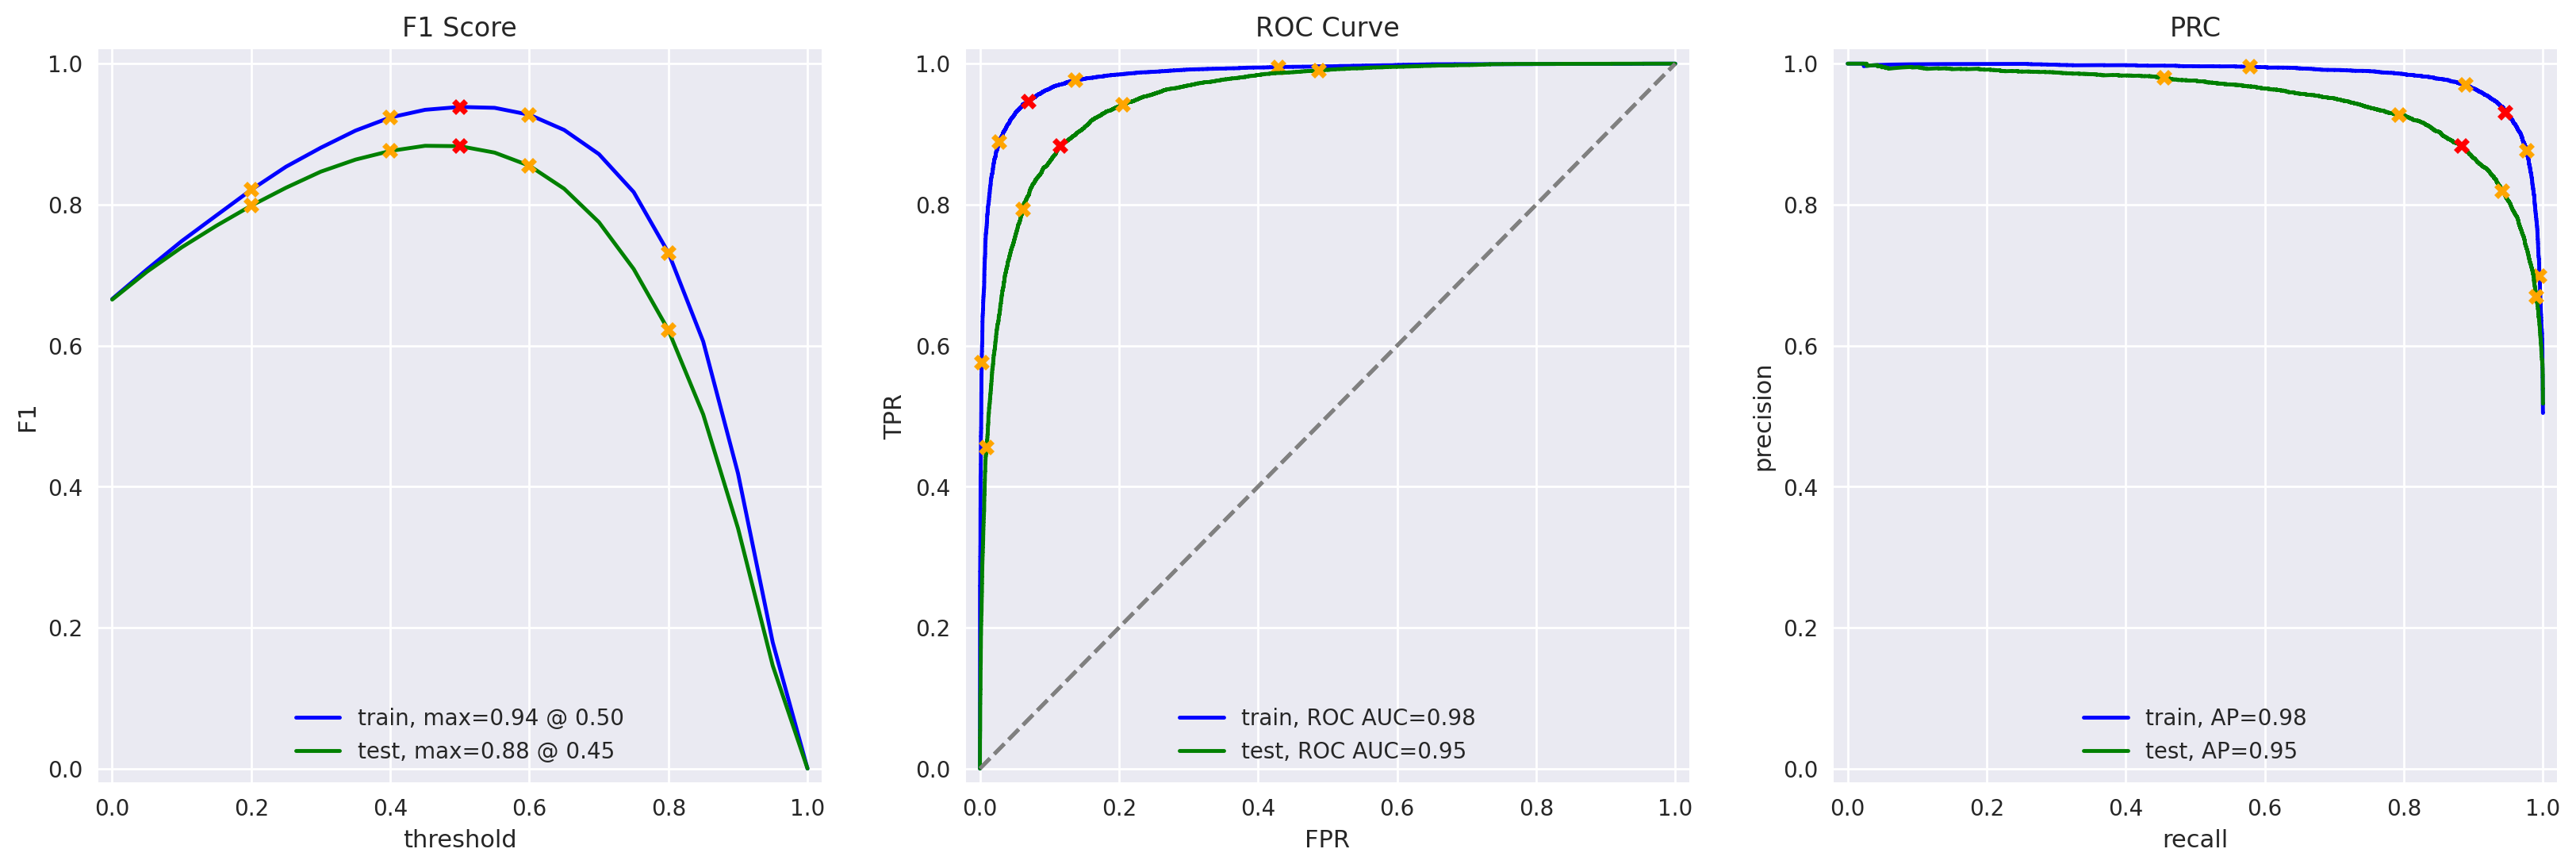

In [23]:
model_2_eval = evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)
print(model_2_eval)

This Model has significantly exceeded the project requirement of F1 ≥ 0.85. The model generalizes well (test performance only slightly lower than train), and 
all metrics are consistently strong across train and test sets. However there seems to be some overfitting (6-point gap between train/test), but it's reasonable
with a substantial improvement over the baseline Model 0 (0.50 → 0.88 accuracy).

In [24]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [25]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [26]:
train_features_spacy = df_reviews_train['review_norm'].apply(text_preprocessing_3)
test_features_spacy = df_reviews_test['review_norm'].apply(text_preprocessing_3)

corpus = train_features_spacy.tolist()
review_idx = random.randint(0, len(corpus) - 1)
review = corpus[review_idx]

tfidf_vectorizer_3 = TfidfVectorizer(stop_words=stop_words)
tf_idf = tfidf_vectorizer_3.fit_transform(corpus)

train_features_3 = tfidf_vectorizer_3.transform(train_features_spacy)
test_features_3 = tfidf_vectorizer_3.transform(test_features_spacy)


model_3 = LogisticRegression()
model_3.fit(train_features_3, train_target)

LogisticRegression()

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95
None


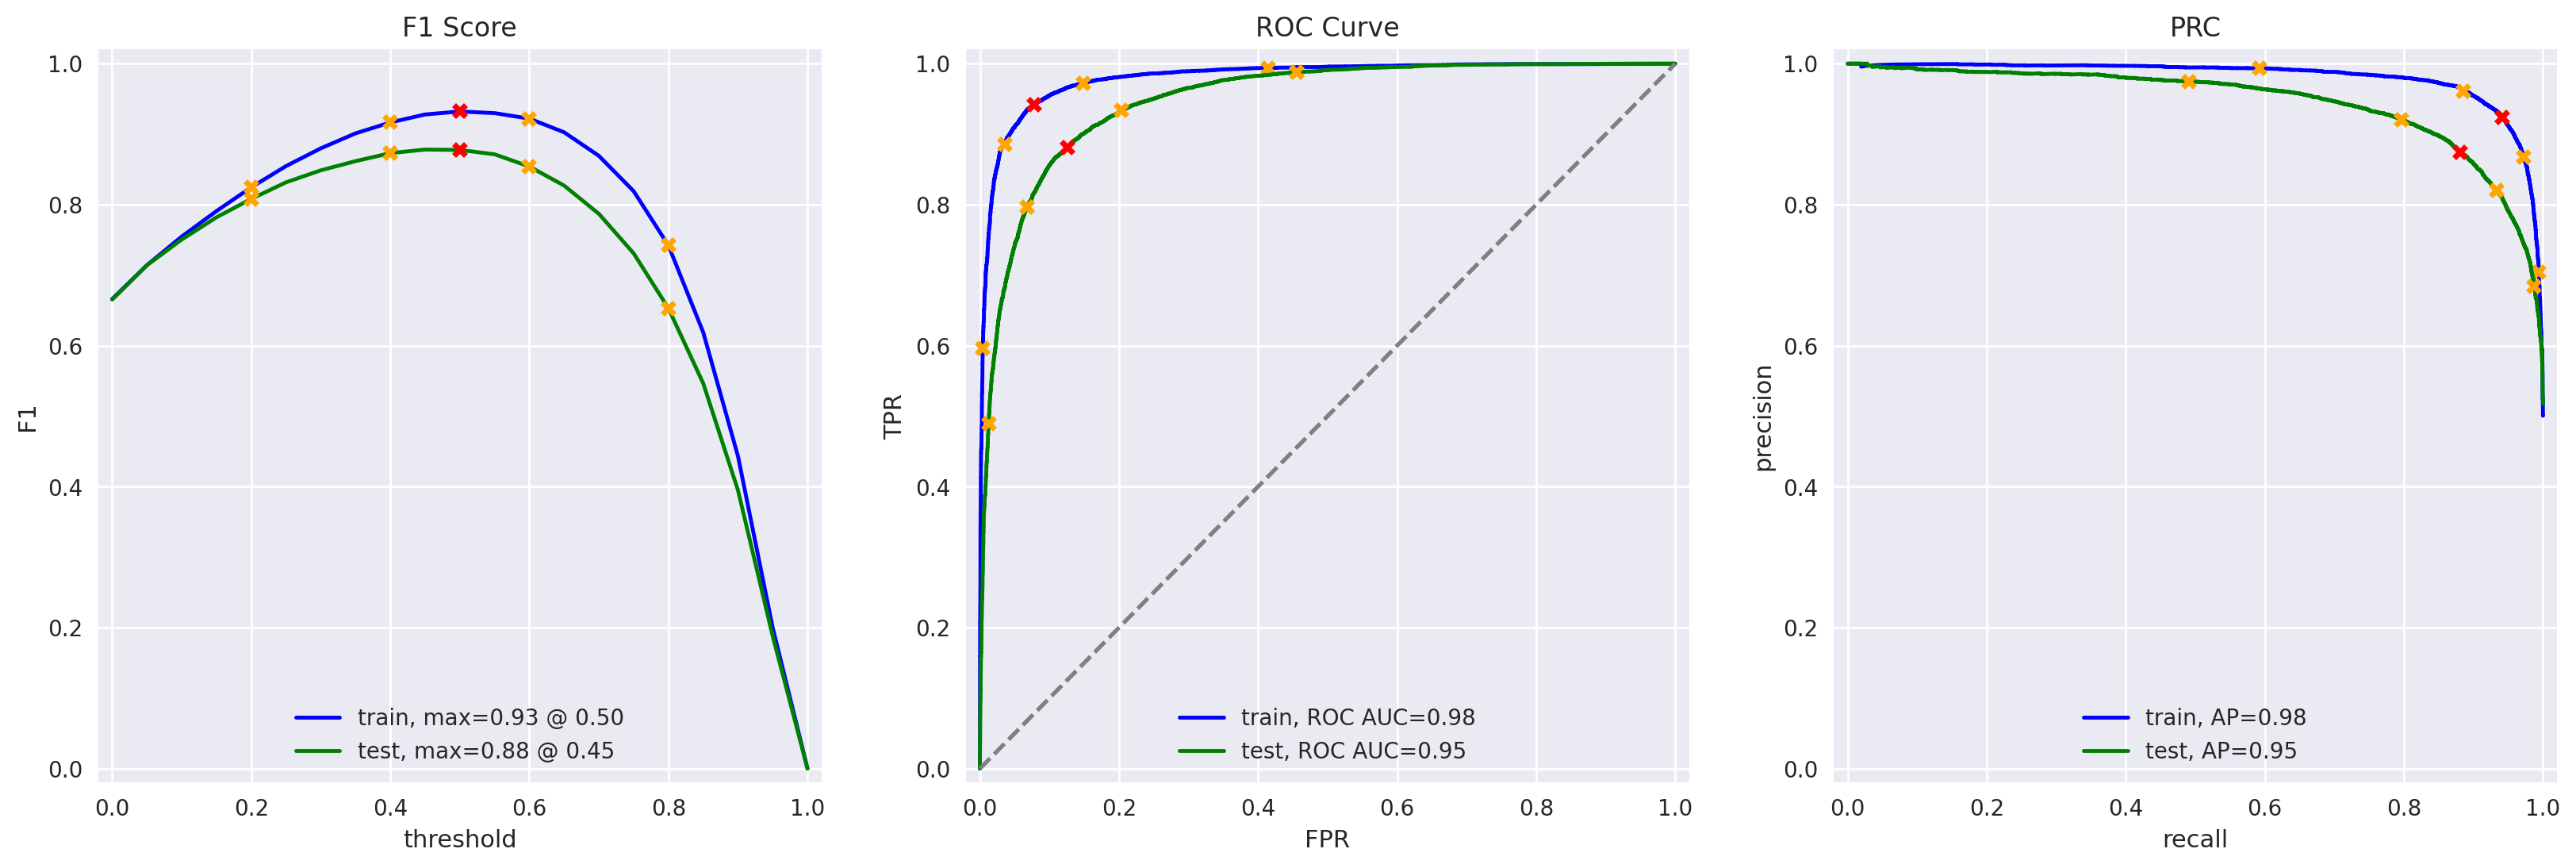

In [27]:
model_3_eval = evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)
print(model_3_eval)

The spaCy lemmatization doesn't seem to provide a significant advantage over the simpler NLTK stopword removal for this particular dataset. Both achieve 88% F1 on test data
Both have similar ROC AUC (0.95) and APS (0.95).

In [28]:
from lightgbm import LGBMClassifier

          train  test
Accuracy   0.91  0.86
F1         0.91  0.86
APS        0.97  0.93
ROC AUC    0.97  0.93
None


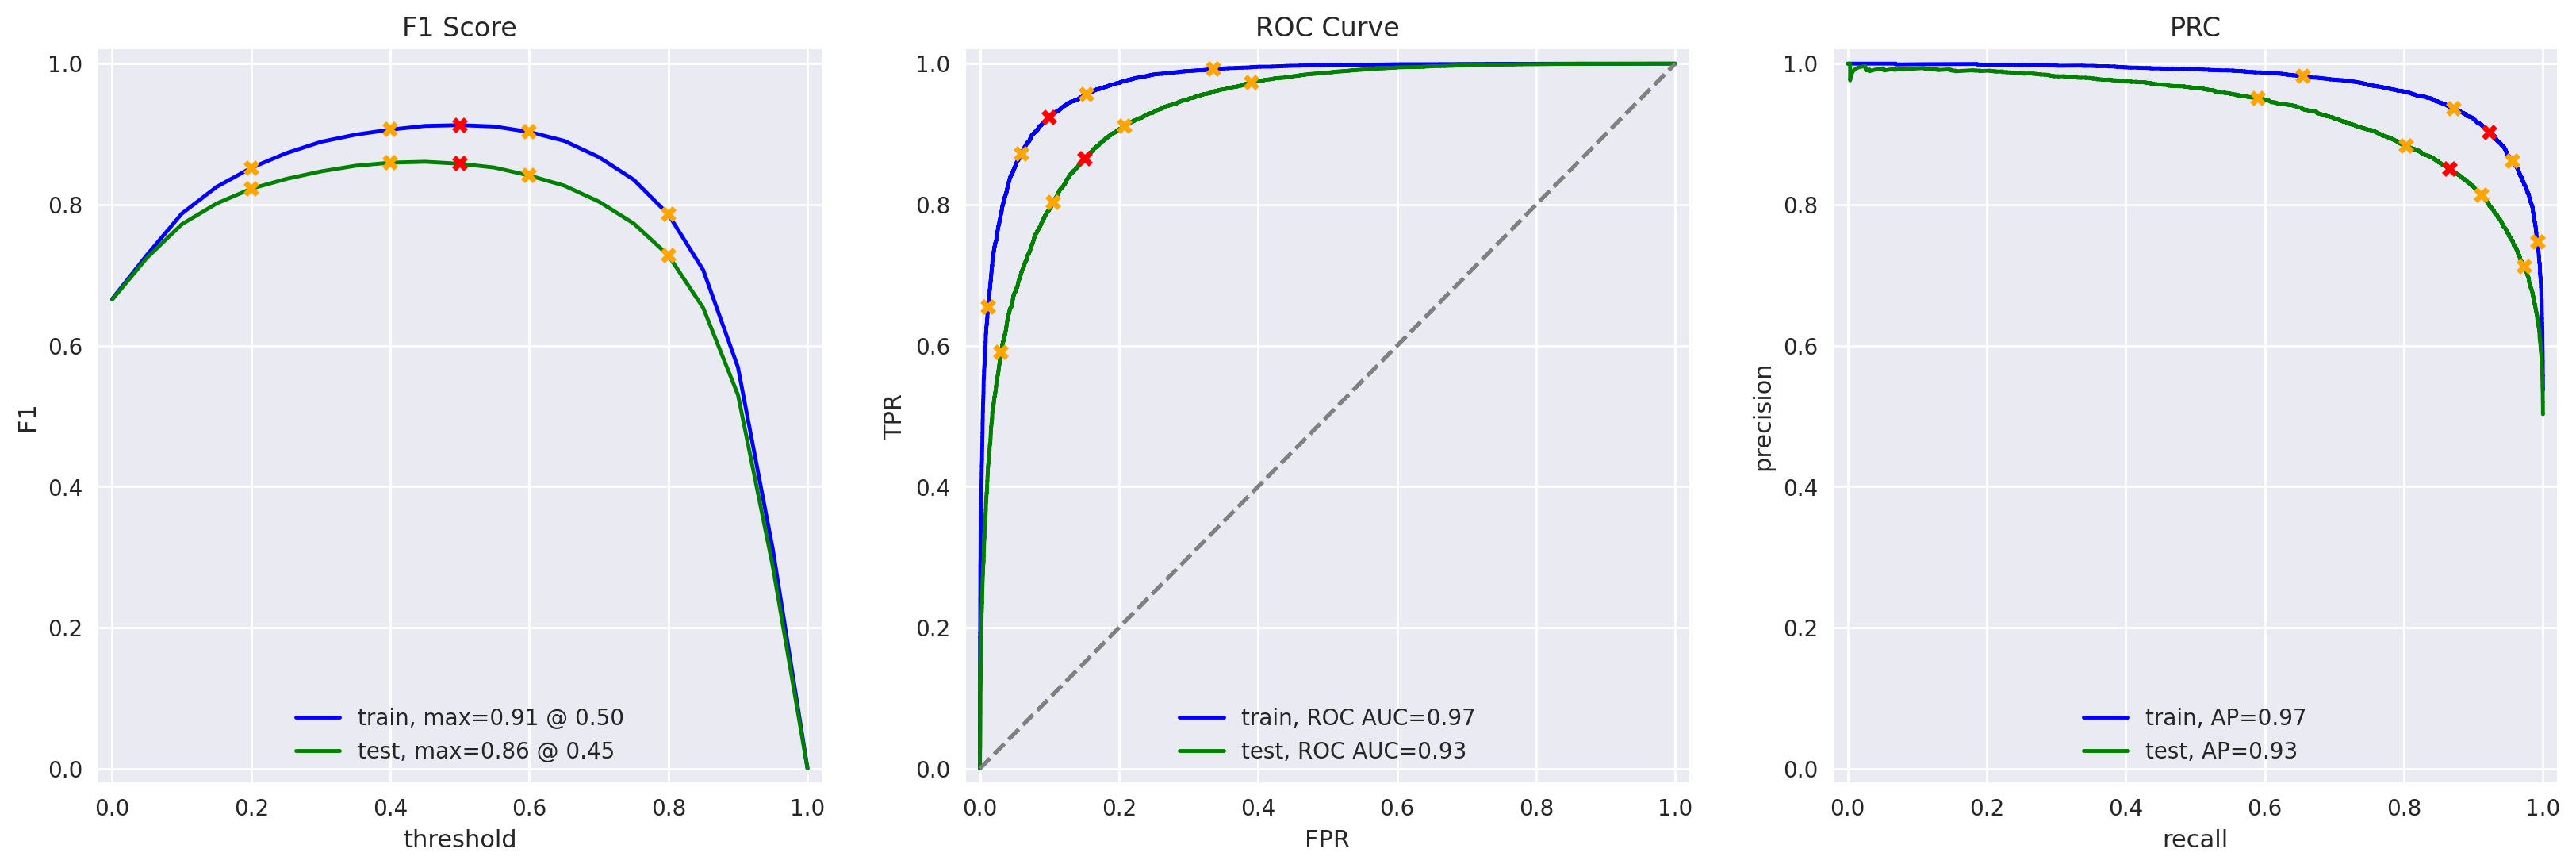

In [29]:

tfidf_vectorizer_4 = tfidf_vectorizer_3
tf_idf = tfidf_vectorizer_4.fit_transform(corpus)

train_features_4 = tfidf_vectorizer_4.transform(train_features_spacy)
test_features_4 = tfidf_vectorizer_4.transform(test_features_spacy)

model_4 = LGBMClassifier()
model_4.fit(train_features_4, train_target)
model_4_eval = evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

print(model_4_eval)


Model 4 achieved strong and balanced performance with a test F1 score of 0.86 (meeting the requirement), accuracy of 0.86, and high ROC AUC and APS scores of 0.93, while showing minimal overfitting due to close train/test results. However, its F1 score is slightly lower than Models 2 and 3 (both 0.88), though it still meets project goals and generalizes well.

In [30]:
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(lambda x: re.sub(r'[^a-z\s]', '', x.lower()))# <put here the same normalization logic as for the main dataset>

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didnt expect the reboot to be so good writer...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i reall...


### Model 2

In [31]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.16:  i did not simply like it not my kind of movie
0.18:  well i was bored and felt asleep in the middle of the movie
0.57:  i was really fascinated with the movie
0.13:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.26:  i didnt expect the reboot to be so good writers really cared about the source material
0.48:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.85:  launching on netflix was a brave move  i really appreciate being able to binge on episode after epis


### Model 3

In [32]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.20:  i did not simply like it not my kind of movie
0.12:  well i was bored and felt asleep in the middle of the movie
0.49:  i was really fascinated with the movie
0.10:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.27:  i didnt expect the reboot to be so good writers really cared about the source material
0.47:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.92:  launching on netflix was a brave move  i really appreciate being able to binge on episode after epis


### Model 4

In [33]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.57:  i did not simply like it not my kind of movie
0.39:  well i was bored and felt asleep in the middle of the movie
0.60:  i was really fascinated with the movie
0.38:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.66:  i didnt expect the reboot to be so good writers really cared about the source material
0.66:  the movie had its upsides and downsides but i feel like overall its a decent flick i could see mysel
0.26:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.78:  launching on netflix was a brave move  i really appreciate being able to binge on episode after epis


In [34]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

def get_model_metrics(model, train_features, train_target, test_features, test_target):
    train_pred = model.predict(train_features)
    test_pred = model.predict(test_features)
    train_proba = model.predict_proba(train_features)[:, 1]
    test_proba = model.predict_proba(test_features)[:, 1]

    metrics = {
        'Model': '',
        'Train_Accuracy': accuracy_score(train_target, train_pred),
        'Test_Accuracy': accuracy_score(test_target, test_pred),
        'Train_F1': f1_score(train_target, train_pred),
        'Test_F1': f1_score(test_target, test_pred),
        'Train_ROC_AUC': roc_auc_score(train_target, train_proba),
        'Test_ROC_AUC': roc_auc_score(test_target, test_proba),
        'Train_APS': average_precision_score(train_target, train_proba),
        'Test_APS': average_precision_score(test_target, test_proba)}
    return metrics

comparison_data = []

models_info = [
    ('Model 1 (Constant)', model_1, train_features, test_features),
    ('Model 2 (NLTK + TF-IDF + LR)', model_2, train_features_2, test_features_2),
    ('Model 3 (spaCy + TF-IDF + LR)', model_3, train_features_3, test_features_3),
    ('Model 4 (spaCy + TF-IDF + LGBM)', model_4, train_features_4, test_features_4)]

for model_name, model, train_feat, test_feat in models_info:
    metrics = get_model_metrics(model, train_feat, train_target, test_feat, test_target)
    metrics['Model'] = model_name
    comparison_data.append(metrics)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(3)

column_order = ['Model', 'Test_F1', 'Test_Accuracy', 'Test_ROC_AUC', 'Test_APS', 
                'Train_F1', 'Train_Accuracy', 'Train_ROC_AUC', 'Train_APS']
comparison_df = comparison_df[column_order]

comparison_df = comparison_df.sort_values('Test_F1', ascending=False).reset_index(drop=True)

comparison_df.insert(0, 'Rank', range(1, len(comparison_df) + 1))

comparison_df['Meets_F1_Requirement'] = comparison_df['Test_F1'] >= 0.85

print("Model Performance Comparison:")
print("="*80)
display(comparison_df)

Model Performance Comparison:


,Rank,Model,Test_F1,Test_Accuracy,Test_ROC_AUC,Test_APS,Train_F1,Train_Accuracy,Train_ROC_AUC,Train_APS,Meets_F1_Requirement
0,1,Model 2 (NLTK + TF-IDF + LR),0.883,0.883,0.952,0.949,0.939,0.938,0.984,0.984,True
1,2,Model 3 (spaCy + TF-IDF + LR),0.878,0.878,0.949,0.946,0.932,0.932,0.980,0.981,True
2,3,Model 4 (spaCy + TF-IDF + LGBM),0.858,0.857,0.935,0.932,0.913,0.912,0.973,0.973,True
3,4,Model 1 (Constant),0.665,0.498,0.500,0.498,0.666,0.499,0.500,0.499,False


For the Film Junky Union project, we successfully developed and evaluated multiple machine learning models to classify IMDb movie reviews as either positive or negative. After preprocessing the data and performing exploratory data analysis, we observed that the dataset was relatively balanced across both classes. This balance reduced the need for resampling techniques and allowed all models to learn effectively from the training data without significant class bias.

Among the models tested, Model 2 (NLTK + TF-IDF + Logistic Regression) achieved the highest performance with a Test F1 score of 0.883, followed closely by Model 3 (spaCy + TF-IDF + Logistic Regression) with an F1 score of 0.878. Both models exceeded the requirement and demonstrated strong performance across additional metrics such as ROC-AUC (0.952 for Model 2 and 0.949 for Model 3) and average precision score (0.949 and 0.946 respectively), indicating highly reliable classification performance. Model 4 (spaCy + TF-IDF + LightGBM) also met the requirement with an F1 score of 0.858, but performed slightly worse than the Logistic Regression models, reinforcing the tendency of linear models to perform better with high-dimensional sparse TF-IDF features. As expected, Model 0 (Constant baseline) performed poorly across all metrics and did not meet the F1 threshold, confirming that meaningful feature-based learning is essential for this task.

When comparing training and test performance, all top models showed relatively consistent results, suggesting good generalization and limited overfitting. Model 2 and Model 3 maintained strong and stable performance across accuracy, ROC-AUC, and APS, indicating robustness across multiple evaluation criteria rather than reliance on a single metric. Overall, while both preprocessing approaches (NLTK and spaCy) were effective, NLTK + TF-IDF + Logistic Regression slightly outperformed the others in this experiment. Therefore, Model 2 is recommended for deployment as the most accurate and well-rounded sentiment classification model for this dataset.